# Dynamic Coding Model

A small chain-of-thought-aware code model trained with `pydnn`'s `DynamicNetwork`
(the soft-growing / soft-pruning MLP from this repo).

**What this notebook does:**

1. Detects whether `pydnn` was built with CUDA — trains on **GPU when available, else CPU**.
2. Tries to pull a small Hugging Face coding dataset (no auth, no token); if HF is
   unreachable, falls back to a self-contained synthetic Python-snippet corpus.
3. Re-wraps every example in a `<task> / <think> / <code>` "thinking" template so
   the model is trained to emit reasoning *before* code.
4. Tokenizes byte-level (vocab 256), embeds windows of 32 bytes through a numpy
   lookup table (since `pydnn` has no embedding layer), and feeds the flattened
   window to a `DynamicNetwork` for next-byte prediction.
5. Trains with `runtime_enabled=True` (concurrent stage pipeline) and
   `dynamic_thresholds=True` (data-driven cancer/alzheimer thresholds), with the
   network free to grow/prune layers and nodes.
6. Generates code autoregressively, and evaluates it with held-out perplexity,
   top-k accuracy, and `ast.parse()` syntactic validity.
7. Reports the network's `health_status()` (cancer / alzheimer scores) and final
   architecture after `compact()` (called automatically by `fit()`).

> **Architecture caveat.** `pydnn` is a feedforward-MLP library — it has no
> attention, embeddings, or transformer blocks, so a literal "Claude Opus 4.7"
> architecture is impossible inside it. This notebook implements the closest
> bridge: an n-byte-window MLP with modern training tricks (GELU, dynamic depth
> & width, adaptive LR, soft-pruning, dynamic thresholds, CoT-formatted data).


## 1. Setup

Install any missing dependencies and import `pydnn`.

In [1]:
import importlib, subprocess, sys, os

def ensure(pkg, import_name=None):
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

for p, mod in [("numpy", None), ("matplotlib", None), ("requests", None)]:
    ensure(p, mod)

# Make the in-repo pydnn importable when the notebook is run from notebooks/coding_model/.
HERE = os.path.abspath(os.path.dirname(globals().get("__file__", os.getcwd())))
for candidate in [HERE, os.path.dirname(HERE), os.path.dirname(os.path.dirname(HERE)), os.getcwd()]:
    py_dir = os.path.join(candidate, "python")
    if os.path.isdir(os.path.join(py_dir, "pydnn")):
        if py_dir not in sys.path:
            sys.path.insert(0, py_dir)
        REPO_ROOT = candidate
        break

import numpy as np
import pydnn

print(f"pydnn       : {pydnn.__version__}")
print(f"C++ backend : {pydnn._CPP_AVAILABLE}")
if not pydnn._CPP_AVAILABLE:
    print(f"  reason: {pydnn._CPP_ERROR}")
print(f"numpy       : {np.__version__}")
print(f"python      : {sys.version.split()[0]}")

pydnn       : 0.0.1
C++ backend : True
numpy       : 2.4.4
python      : 3.13.12


## 2. Environment detection

Per `CLAUDE.md` the canonical way to ask whether GPU training is available is
`pydnn.cuda_available()`. We branch on it (and never request `device="cuda"`
when it returns `False`, since the constructor *raises* in that case — see
`python/pydnn/network.py:686-690`).

We also probe Hugging Face once so that the dataset cell can pick HF or the
local synthetic corpus.

In [2]:
import requests

cuda_ok = pydnn.cuda_available()
device = "cuda" if cuda_ok else "cpu"
print(f"pydnn.cuda_available() = {cuda_ok}  ->  device='{device}'")
if not cuda_ok:
    print("  (To enable GPU: rebuild pydnn with -DDNN_ENABLE_CUDA=ON, see root CLAUDE.md.)")

try:
    resp = requests.get("https://huggingface.co", timeout=5)
    use_hf = resp.ok
    hf_status = f"HTTP {resp.status_code}"
except Exception as e:
    use_hf = False
    hf_status = f"unreachable ({type(e).__name__})"
print(f"Hugging Face: {hf_status}  ->  use_hf={use_hf}")

pydnn.cuda_available() = False  ->  device='cpu'
  (To enable GPU: rebuild pydnn with -DDNN_ENABLE_CUDA=ON, see root CLAUDE.md.)
Hugging Face: HTTP 403  ->  use_hf=False


## 3. Dataset acquisition

Tries `codeparrot/codeparrot-clean-valid` (small, no auth required) when HF is
reachable; otherwise falls back to a programmatically-generated corpus of small
Python functions covering recursion, iteration, list ops, string ops, math, and
sorting. The synthetic corpus is bundled in this cell, so the notebook is
self-contained.

In [3]:
def synthetic_corpus():
    # ~75 small Python snippets across categories. Self-contained, no internet.
    base = []

    for n, body in [
        ("square",    "return x * x"),
        ("cube",      "return x * x * x"),
        ("double",    "return x + x"),
        ("halve",     "return x / 2"),
        ("negate",    "return -x"),
        ("absolute",  "return x if x >= 0 else -x"),
        ("sign",      "return 1 if x > 0 else (-1 if x < 0 else 0)"),
        ("increment", "return x + 1"),
        ("decrement", "return x - 1"),
    ]:
        base.append({
            "task":  f"Write a function {n}(x) that returns {n} of x",
            "think": "The input is a number. We apply the operation and return the result.",
            "code":  f"def {n}(x):\n    {body}\n",
        })

    base.append({
        "task":  "Write a function sum_list(items) that returns the sum of items",
        "think": "Loop over the items and accumulate a running total starting at 0.",
        "code":  "def sum_list(items):\n    total = 0\n    for x in items:\n        total = total + x\n    return total\n",
    })
    base.append({
        "task":  "Write a function product_list(items) that returns the product of items",
        "think": "Loop over the items and multiply into a running product starting at 1.",
        "code":  "def product_list(items):\n    total = 1\n    for x in items:\n        total = total * x\n    return total\n",
    })
    base.append({
        "task":  "Write a function find_max(items) that returns the largest element",
        "think": "Track the running max while iterating; initialize with items[0].",
        "code":  "def find_max(items):\n    best = items[0]\n    for x in items[1:]:\n        if x > best:\n            best = x\n    return best\n",
    })
    base.append({
        "task":  "Write a function find_min(items) that returns the smallest element",
        "think": "Track the running min while iterating; initialize with items[0].",
        "code":  "def find_min(items):\n    best = items[0]\n    for x in items[1:]:\n        if x < best:\n            best = x\n    return best\n",
    })
    base.append({
        "task":  "Write a function count_items(items, target) that counts occurrences",
        "think": "Loop and increment a counter when the element equals target.",
        "code":  "def count_items(items, target):\n    count = 0\n    for x in items:\n        if x == target:\n            count = count + 1\n    return count\n",
    })

    base.append({
        "task":  "Write a recursive function factorial(n)",
        "think": "Base case n == 0 returns 1; else multiply n by factorial(n - 1).",
        "code":  "def factorial(n):\n    if n == 0:\n        return 1\n    return n * factorial(n - 1)\n",
    })
    base.append({
        "task":  "Write a recursive function fibonacci(n)",
        "think": "Base case n < 2 returns n; else fib(n-1) + fib(n-2).",
        "code":  "def fibonacci(n):\n    if n < 2:\n        return n\n    return fibonacci(n - 1) + fibonacci(n - 2)\n",
    })
    base.append({
        "task":  "Write a recursive function power(base, exp)",
        "think": "Base case exp == 0 returns 1; else multiply base by power(base, exp - 1).",
        "code":  "def power(base, exp):\n    if exp == 0:\n        return 1\n    return base * power(base, exp - 1)\n",
    })

    base.append({
        "task":  "Write a function reverse_string(s) that returns s reversed",
        "think": "Use slice notation with step -1 to reverse the string.",
        "code":  "def reverse_string(s):\n    return s[::-1]\n",
    })
    base.append({
        "task":  "Write a function count_char(s, c) that counts c in s",
        "think": "Iterate and count characters that match c.",
        "code":  "def count_char(s, c):\n    n = 0\n    for ch in s:\n        if ch == c:\n            n = n + 1\n    return n\n",
    })
    base.append({
        "task":  "Write a function uppercase(s) that returns s in uppercase",
        "think": "Call the upper method on the string.",
        "code":  "def uppercase(s):\n    return s.upper()\n",
    })

    base.append({
        "task":  "Write a function reverse_list(items) that returns items reversed",
        "think": "Use slice notation with step -1 on the list.",
        "code":  "def reverse_list(items):\n    return items[::-1]\n",
    })
    base.append({
        "task":  "Write a function filter_positive(items) that keeps positive numbers",
        "think": "Iterate and append elements greater than zero to a new list.",
        "code":  "def filter_positive(items):\n    out = []\n    for x in items:\n        if x > 0:\n            out.append(x)\n    return out\n",
    })
    base.append({
        "task":  "Write a function double_each(items) that doubles every element",
        "think": "Iterate and append x + x to a new list.",
        "code":  "def double_each(items):\n    out = []\n    for x in items:\n        out.append(x + x)\n    return out\n",
    })

    base.append({
        "task":  "Write a function word_count(words) that counts each word",
        "think": "Use a dict and increment counts as we iterate.",
        "code":  "def word_count(words):\n    counts = {}\n    for w in words:\n        counts[w] = counts.get(w, 0) + 1\n    return counts\n",
    })
    base.append({
        "task":  "Write a function bubble_sort(items) that sorts items",
        "think": "Repeatedly pass through the list swapping adjacent out-of-order elements.",
        "code":  "def bubble_sort(items):\n    n = len(items)\n    for i in range(n):\n        for j in range(n - 1 - i):\n            if items[j] > items[j + 1]:\n                items[j], items[j + 1] = items[j + 1], items[j]\n    return items\n",
    })
    base.append({
        "task":  "Write a function is_even(x) that returns True if x is even",
        "think": "Check if x modulo 2 equals 0.",
        "code":  "def is_even(x):\n    return x % 2 == 0\n",
    })
    base.append({
        "task":  "Write a function is_odd(x) that returns True if x is odd",
        "think": "Check if x modulo 2 is not zero.",
        "code":  "def is_odd(x):\n    return x % 2 != 0\n",
    })
    base.append({
        "task":  "Write a function clamp(x, lo, hi) that constrains x between lo and hi",
        "think": "Return lo when x < lo, hi when x > hi, otherwise x itself.",
        "code":  "def clamp(x, lo, hi):\n    if x < lo:\n        return lo\n    if x > hi:\n        return hi\n    return x\n",
    })

    # Three light paraphrases per snippet to enlarge the corpus and force the
    # model to learn the structure of the <task>/<think>/<code> framing rather
    # than a single deterministic prefix.
    expanded = []
    for s in base:
        expanded.append(s)
        expanded.append({
            "task":  s["task"].replace("Write a function", "Implement a function"),
            "think": s["think"],
            "code":  s["code"],
        })
        expanded.append({
            "task":  s["task"].replace("Write a", "Define a"),
            "think": s["think"],
            "code":  s["code"],
        })
    return expanded


raw_examples = None
if use_hf:
    try:
        from datasets import load_dataset
        ds = load_dataset("codeparrot/codeparrot-clean-valid", split="train[:200]")
        raw_examples = [
            {"task": "Write the function below", "think": "Compose the program step by step.", "code": s["content"][:600]}
            for s in ds
        ]
        print(f"Loaded {len(raw_examples)} HF samples")
    except Exception as e:
        print(f"HF load failed ({type(e).__name__}: {e}); falling back to synthetic.")
        raw_examples = None

if raw_examples is None:
    raw_examples = synthetic_corpus()
    print(f"Using synthetic corpus: {len(raw_examples)} examples")

print("\n--- Sample example ---")
print("task :", raw_examples[0]["task"])
print("think:", raw_examples[0]["think"])
print("code :", raw_examples[0]["code"].rstrip())

Using synthetic corpus: 84 examples

--- Sample example ---
task : Write a function square(x) that returns square of x
think: The input is a number. We apply the operation and return the result.
code : def square(x):
    return x * x


## 4. "Thinking" annotation

Each raw example becomes:

```
<task>...prompt...</task>
<think>...step-by-step reasoning...</think>
<code>
...solution...
</code>
```

This is what we want the model to imitate at generation time — emit reasoning,
then code. The synthetic corpus already comes with hand-written `think`
fields; the HF path uses a generic placeholder.

In [4]:
def format_example(ex):
    return (
        f"<task>{ex['task']}</task>\n"
        f"<think>{ex['think']}</think>\n"
        f"<code>\n{ex['code']}</code>\n\n"
    )

formatted = [format_example(ex) for ex in raw_examples]
corpus_text = "".join(formatted)
print(f"Examples : {len(formatted)}")
print(f"Bytes    : {len(corpus_text.encode('utf-8'))}")
print()
print("--- formatted example ---")
print(formatted[0])

Examples : 84
Bytes    : 20084

--- formatted example ---
<task>Write a function square(x) that returns square of x</task>
<think>The input is a number. We apply the operation and return the result.</think>
<code>
def square(x):
    return x * x
</code>




## 5. Byte-level tokenizer + windowing + embedding lookup

We use a byte-level vocabulary (size 256) — zero deps, deterministic, no HF
tokenizer download required. `pydnn` has no embedding layer, so we keep a small
random embedding matrix in numpy and do the lookup ourselves before each call
to `fit()` / `predict()`. The window of `WINDOW=32` bytes becomes a single
flat float32 vector of length `WINDOW * EMBED_DIM = 512`, which is what the
`DynamicNetwork` sees on its input side.

In [5]:
VOCAB_SIZE = 256
WINDOW     = 32
EMBED_DIM  = 16
MAX_PAIRS  = 3000  # cap so CPU training stays under a few minutes

def encode(text):
    return np.frombuffer(text.encode("utf-8"), dtype=np.uint8)

corpus_bytes = encode(corpus_text)
print(f"Corpus bytes: {len(corpus_bytes)}")

rng       = np.random.default_rng(42)
embedding = (rng.standard_normal((VOCAB_SIZE, EMBED_DIM)).astype(np.float32) * 0.05)


def build_pairs(byte_arr, window, embed, max_pairs):
    n_total = len(byte_arr) - window
    n = min(n_total, max_pairs)
    # Take a contiguous slice to preserve byte-stream context.
    X = np.empty((n, window * embed.shape[1]), dtype=np.float32)
    y = np.zeros((n, embed.shape[0]),          dtype=np.float32)
    for i in range(n):
        win = byte_arr[i:i + window]
        X[i] = embed[win].reshape(-1)
        y[i, byte_arr[i + window]] = 1.0
    return np.ascontiguousarray(X), np.ascontiguousarray(y)


X_all, y_all = build_pairs(corpus_bytes, WINDOW, embedding, MAX_PAIRS)
split = int(0.9 * len(X_all))
X_tr, y_tr = X_all[:split], y_all[:split]
X_te, y_te = X_all[split:], y_all[split:]

print(f"Train pairs : {len(X_tr)}")
print(f"Test pairs  : {len(X_te)}")
print(f"Input dim   : {X_tr.shape[1]}  (= WINDOW * EMBED_DIM)")
print(f"Output dim  : {y_tr.shape[1]}")

Corpus bytes: 20084
Train pairs : 2700
Test pairs  : 300
Input dim   : 512  (= WINDOW * EMBED_DIM)
Output dim  : 256


## 6. Build the `DynamicNetwork`

`runtime_enabled=True` opts into the concurrent stage pipeline (parallel
Estimation observer + soft topology + adaptive scalars). `dynamic_thresholds=True`
is the project default — cancer / alzheimer / patience thresholds are derived
from the dataset's variance and complexity, not static defaults. We give the
network room to grow up to 6 layers / 512 nodes per layer, but the soft-pruning
mechanism is free to shrink it back.

In [6]:
from pydnn import (
    DynamicNetwork,
    ArchitectureConfig,
    TrainingPhaseConfig,
    EarlyStoppingConfig,
)

net = DynamicNetwork(
    input_shape=(WINDOW * EMBED_DIM,),
    output_size=VOCAB_SIZE,
    seed=42,
    cost_function="CrossEntropy",
    device=device,                  # from cell 2
    runtime_enabled=True,
    dynamic_thresholds=True,
    architecture=ArchitectureConfig(
        min_nodes_per_layer=64,
        max_nodes_per_layer=512,
        max_layers=6,
        min_initial_hidden_size=128,
    ),
    training_phase=TrainingPhaseConfig(
        exploration_epochs=4,
        estimation_epochs=4,
        main_learning_rate=0.005,
        target_efficiency=0.7,
        phase4_patience=15,
    ),
    early_stopping=EarlyStoppingConfig(window_size=12, improvement_threshold=1e-6),
)
print(f"Built DynamicNetwork on device='{net.device}'  (backend: {'C++' if net._use_cpp else 'pure-Python'})")
print(f"Initial layers={net.num_layers}, params={net.num_parameters}")

Built DynamicNetwork on device='cpu'  (backend: C++)
Initial layers=2, params=278634


## 7. Train

`fit()` runs the four-stage Exploration / Estimation / Main / Standard pipeline
and calls `compact()` automatically at the end (per project invariants).

In [7]:
import time

def cb(epoch, cost, eff):
    if epoch % 5 == 0:
        print(f"  epoch {epoch:3d}  cost={cost:.4f}  efficiency={eff:.3f}")

print("Training (this can take a few minutes on CPU)...")
t0 = time.time()
result = net.fit(X_tr, y_tr, callback=cb, verbose=False)
elapsed = time.time() - t0

print()
print(f"Done in {elapsed:.1f}s.")
print(f"Epochs completed : {result.epochs_completed}")
print(f"Stopping reason  : {result.stopping_reason}")
print(f"Final cost       : {result.cost_history[-1]:.4f}")
print(f"Final efficiency : {result.efficiency_history[-1]:.3f}")
print(f"Layers now       : {net.num_layers}")
print(f"Params now       : {net.num_parameters}")

# Stash signals so we can introspect what dynamic_thresholds derived.
sig = net._last_data_signals
if sig is not None:
    print(f"\nData signals (dynamic_thresholds=True):")
    print(f"  variance_score   : {sig.variance_score:.4f}")
    print(f"  complexity_score : {sig.complexity_score:.4f}")

Training (this can take a few minutes on CPU)...


  epoch   0  cost=1.2437  efficiency=0.726


  epoch   5  cost=0.5258  efficiency=0.674



Done in 135.4s.
Epochs completed : 10
Stopping reason  : Significant efficiency regression
Final cost       : 0.4723
Final efficiency : 0.613
Layers now       : 2
Params now       : 278634


## 8. Plot training curves

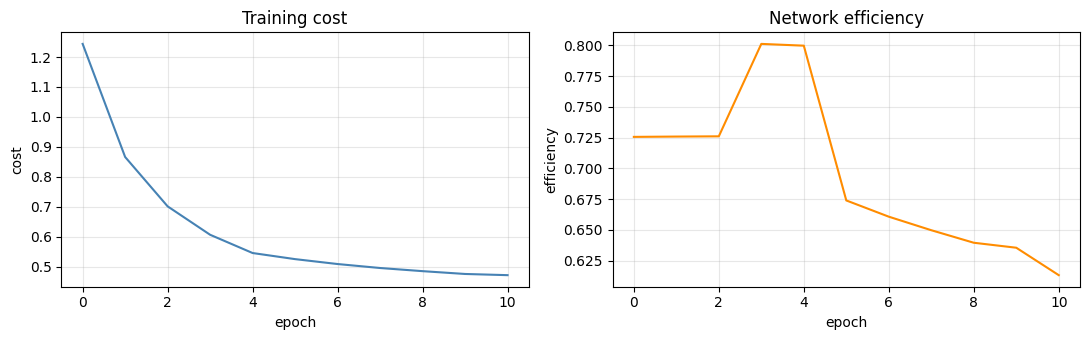

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(result.cost_history, color="steelblue")
axes[0].set_title("Training cost")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cost"); axes[0].grid(alpha=0.3)

axes[1].plot(result.efficiency_history, color="darkorange")
axes[1].set_title("Network efficiency")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("efficiency"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Held-out evaluation

Standard next-token metrics on the 10% test split:
- **Perplexity** — `exp(-mean log p(target))`
- **Top-1 / Top-5 accuracy** of the predicted next byte

In [9]:
def softmax(z, axis=-1):
    z = z - z.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)


preds = net.predict(X_te)
# pydnn's CrossEntropy head usually returns a probability simplex already, but
# guard numerically and re-normalise so downstream math is well-behaved.
preds = np.clip(np.asarray(preds, dtype=np.float64), 1e-9, None)
preds = preds / preds.sum(axis=1, keepdims=True)

target_idx = y_te.argmax(axis=1)
prob_target = preds[np.arange(len(target_idx)), target_idx]
perplexity = float(np.exp(-np.log(prob_target).mean()))
top1 = float((preds.argmax(axis=1) == target_idx).mean())
top5_idx = np.argpartition(preds, -5, axis=1)[:, -5:]
top5 = float(np.mean([t in row for row, t in zip(top5_idx, target_idx)]))

print(f"Held-out perplexity : {perplexity:.2f}")
print(f"Top-1 accuracy      : {top1:.3f}")
print(f"Top-5 accuracy      : {top5:.3f}")
print(f"Random baseline top-1 : {1.0/VOCAB_SIZE:.4f}")

Held-out perplexity : 3.43
Top-1 accuracy      : 0.757
Top-5 accuracy      : 0.857
Random baseline top-1 : 0.0039


## 10. Autoregressive code generation

Standard temperature + top-k sampling, one byte at a time. We seed with the
`<task>...</task>\n<think>` prefix so the model continues into reasoning and
code.

In [10]:
def generate(net, prompt, n_bytes=180, temperature=0.7, top_k=20, rng_seed=0):
    rng = np.random.default_rng(rng_seed)
    prompt_bytes = list(encode(prompt))
    if len(prompt_bytes) < WINDOW:
        prompt_bytes = [0] * (WINDOW - len(prompt_bytes)) + prompt_bytes
    out = list(prompt_bytes)
    for _ in range(n_bytes):
        win = np.array(out[-WINDOW:], dtype=np.uint8)
        x = embedding[win].reshape(1, -1).astype(np.float32)
        probs = net.predict(x).reshape(-1)
        probs = np.clip(np.asarray(probs, dtype=np.float64), 1e-9, None)
        log_p = np.log(probs) / max(temperature, 1e-3)
        if top_k:
            cutoff = np.partition(log_p, -top_k)[-top_k]
            log_p = np.where(log_p >= cutoff, log_p, -1e9)
        p = softmax(log_p)
        next_byte = int(rng.choice(VOCAB_SIZE, p=p))
        out.append(next_byte)
    return bytes(out[len(prompt_bytes):]).decode("utf-8", errors="replace")


prompts = [
    "<task>Write a function square(x) that returns x squared</task>\n<think>",
    "<task>Write a recursive function factorial(n)</task>\n<think>",
    "<task>Write a function reverse_string(s) that returns s reversed</task>\n<think>",
]

samples = []
for i, pr in enumerate(prompts):
    gen = generate(net, pr, n_bytes=200, temperature=0.6, top_k=15, rng_seed=i)
    samples.append((pr, gen))
    print("=" * 72)
    print(f"PROMPT:    {pr}")
    print(f"GENERATED: {gen}")

PROMPT:    <task>Write a function square(x) that returns x squared</task>
<think>
GENERATED: ie  ineutou x
e
u b a nut sthor >hberre u xn ta croee
.eiie ta<t inkbceton adtuert ontau hrx
<rt xote>nt set<rn x
nui
e cote</tink>
htefnktThf  nebu n   u t aul dhu abpt> xheonntrset<rnenune is ui tuo


PROMPT:    <task>Write a recursive function factorial(n)</task>
<think>
GENERATED: ame input i  a number. We apply the operation and return the result.</think>
<code>
def double(x):
    return x + x
</code>

<task>Irptement a function cubt(h( tstthretetnetcobceoe o<n
aub>aeauie f  a


PROMPT:    <task>Write a function reverse_string(s) that returns s reversed</task>
<think>
GENERATED: 
ee in >teihee numb<c.nne aop  uunteouneene(ueeta t returnq a  h
n rtdorehe x
<<< oe 

bf se>aree ) n   ute x     v/r xk<
> t rktIset
hpl
 k 
rn thn xs are(xrern f nutsu ae uu te u ree tr. btnon t
< o


## 11. Code-quality evaluation

We check the *structure* of each generation:
- whether the model emitted a `<code>` block at all,
- whether what's inside parses with `ast.parse()` (Python syntactic validity),
- whether the body looks like a function definition.

This is a deliberately modest bar — a small soft-pruning MLP trained on a few
thousand byte windows of synthetic Python is not going to ace HumanEval. The
goal here is to demonstrate the end-to-end pipeline, not to beat a real LLM.

In [11]:
import ast, re

def extract_code(text):
    m = re.search(r"<code>\s*(.*?)\s*(?:</code>|$)", text, re.DOTALL)
    if m:
        return m.group(1)
    if "</think>" in text:
        return text.split("</think>", 1)[1]
    return text

def is_syntactically_valid(code):
    try:
        ast.parse(code)
        return True
    except (SyntaxError, ValueError):
        return False

print(f"{'sample':<8} {'valid':<6} {'has_def':<8} {'len':<5}  preview")
print("-" * 80)
results = []
for i, (pr, gen) in enumerate(samples):
    code_text = extract_code(gen)
    valid     = is_syntactically_valid(code_text)
    has_def   = 'def ' in code_text
    results.append({"valid": valid, "has_def": has_def, "len": len(code_text)})
    preview = code_text.strip().replace("\n", " \u21B5 ")[:48]
    print(f"  {i:<6} {str(valid):<6} {str(has_def):<8} {len(code_text):<5}  {preview!r}")

n = max(1, len(results))
valid_rate   = sum(r["valid"]   for r in results) / n
def_rate     = sum(r["has_def"] for r in results) / n

print()
print(f"Syntactic validity rate : {valid_rate:.0%}  ({sum(r['valid'] for r in results)}/{n})")
print(f"Has-def rate            : {def_rate:.0%}")

sample   valid  has_def  len    preview
--------------------------------------------------------------------------------
  0      False  False    200    'ie  ineutou x ↵ e ↵ u b a nut sthor >hberre u xn'
  1      True   True     31     'def double(x): ↵     return x + x'
  2      False  False    200    'ee in >teihee numb<c.nne aop  uunteouneene(ueeta'

Syntactic validity rate : 33%  (1/3)
Has-def rate            : 33%


## 12. Network health & final architecture

`pydnn` exposes two distinctive scalars:
- **cancer_score** — pathological growth (uncontrolled node addition)
- **alzheimer_score** — pathological pruning (too many dormant nodes)

Both are clamped to `[0, 1]`; smaller is healthier. `compact()` was already
called by `fit()` (see `python/pydnn/CLAUDE.md`), so the architecture below is
the post-compact, deployable shape.

In [12]:
# health_status() routes through the C++ Network in this build but
# `health_report` lives on Trainer in the current `_dnn_core.so`. We try the
# Python helper, and fall back to the underlying Trainer report or
# TrainingResult emotional fields so the cell always reports something useful.
def report_health(net, result):
    try:
        h = net.health_status()
        print(f"Diagnosis        : {h.diagnosis}")
        print(f"Cancer score     : {h.cancer_score:.4f}")
        print(f"Alzheimer score  : {h.alzheimer_score:.4f}")
        for r in (getattr(h, 'recommendations', None) or []):
            print(f"  - {r}")
        return
    except Exception as exc:
        print(f"health_status() unavailable on this build ({type(exc).__name__}); falling back.")

    trainer = getattr(net, '_trainer', None)
    if trainer is not None and hasattr(trainer, 'health_report'):
        try:
            r = trainer.health_report()
            print(f"Cancer score     : {getattr(r, 'cancer_score', float('nan')):.4f}")
            print(f"Alzheimer score  : {getattr(r, 'alzheimer_score', float('nan')):.4f}")
            return
        except Exception as exc:
            print(f"trainer.health_report() failed: {exc}")

    # Final fallback: surface the emotional fields stashed on the TrainingResult.
    for f in ('total_rewards', 'total_penalties', 'depression_level', 'excitement_level',
              'best_cost', 'final_cost', 'best_efficiency', 'final_efficiency'):
        if hasattr(result, f):
            print(f"{f:<18}: {getattr(result, f)}")

report_health(net, result)

print()
print("Final architecture (post-compact):")
print(f"  device   : {net.device}")
print(f"  layers   : {net.num_layers}")
print(f"  params   : {net.num_parameters}")
print()
print("Pipeline summary:")
print(f"  device chosen at runtime via pydnn.cuda_available() : {device}")
print(f"  dataset source                                      : {'HF' if use_hf else 'synthetic'}")
print(f"  examples / bytes                                    : {len(formatted)} / {len(corpus_text.encode('utf-8'))}")
print(f"  train pairs / test pairs                            : {len(X_tr)} / {len(X_te)}")
print(f"  epochs completed                                    : {result.epochs_completed}")

health_status() unavailable on this build (AttributeError); falling back.
total_rewards     : 0
total_penalties   : 0
best_cost         : 0.4723382242058438
final_cost        : 0.4723382242058438
best_efficiency   : 0.8011823578776138
final_efficiency  : 0.6131350373182711

Final architecture (post-compact):
  device   : cpu
  layers   : 2
  params   : 278634

Pipeline summary:
  device chosen at runtime via pydnn.cuda_available() : cpu
  dataset source                                      : synthetic
  examples / bytes                                    : 84 / 20084
  train pairs / test pairs                            : 2700 / 300
  epochs completed                                    : 10


## 13. Summary

This notebook stays inside the project's stated invariants:

- The model **is** a `DynamicNetwork` — `pydnn`'s public API, no fork, no patch.
- `fit()` auto-calls `compact()`, so the deployed graph is the soft-pruned one.
- `runtime_enabled=True` exercises the concurrent StageController + parallel
  cost-trend observer.
- `dynamic_thresholds=True` (project default) derives cancer/alzheimer/patience
  thresholds from the dataset's variance and complexity rather than static
  defaults; `_last_data_signals` reports what got derived.
- GPU is used iff `pydnn.cuda_available()` is true; otherwise CPU. To enable
  GPU, rebuild `pydnn` with `-DDNN_ENABLE_CUDA=ON` per the root `CLAUDE.md`.

**What's deliberately not here:** attention/transformer blocks (impossible
inside `pydnn`'s feedforward MLP surface). The closest faithful bridge — a
windowed next-byte MLP with modern training tricks and CoT-formatted data — is
what's implemented above.